In [29]:
import numpy as np
import matplotlib.pyplot as plt


# Parameters
F = 3 # Catalyst activity multiplication factor
a0 = 8.88522E-3 # mol/(s kg_cat bar^2)
b0 = 2.226 # /bar
Ea = 3.737E4 # J/mol
DbH = -6.837E3 # J/mol
Ru = 8.3144 # J/(K mol)
T_0 = 298 # K
P = 1 # bar

a = a0*np.exp(Ea/Ru*(1/493.15-1/T_0))
b = b0*np.exp(DbH/Ru*(1/493.15-1/T_0))

The highest reaction rate is reached when P_CO is  0.11111111111111112  atm.


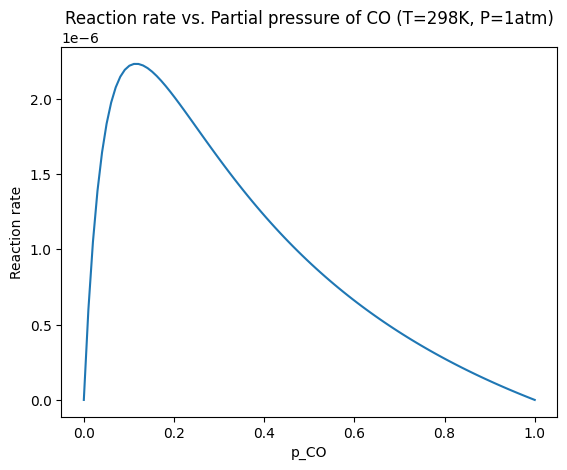

In [30]:
# Partial pressure
Np = np.linspace(0,1,100)
Nr = []
for i in range(len(Np)):
    P_CO = Np[i]*P
    P_H2 = (1-P_CO)*P
    r = (F*a*P_CO*P_H2)/((1+b*P_CO)**2)
    Nr.append(r)

Nr = np.array(Nr)
max_index = np.argmax(Nr)
max_Np = Np[max_index]
max_r = Nr[max_index]
print("The highest reaction rate is reached when P_CO is ",max_Np," atm.")

plt.plot(Np,Nr)
plt.xlabel("p_CO")
plt.ylabel("Reaction rate")
plt.title("Reaction rate vs. Partial pressure of CO (T=298K, P=1atm)")
plt.show()

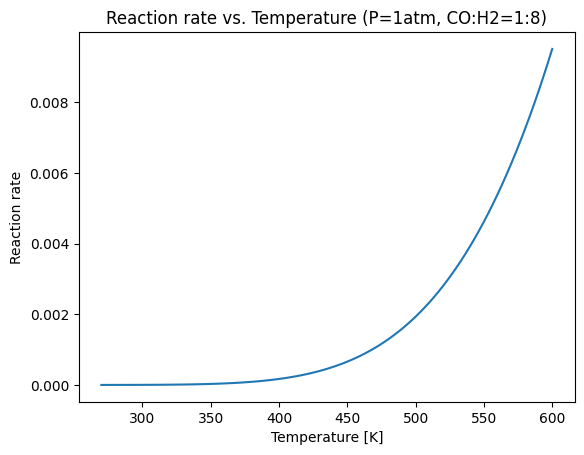

In [31]:
# Temperature
NT = np.linspace(270,600,100)
P_CO_T = 0.111
P_H2_T = 0.889
Nr_T = []
for i in range(len(NT)):
    T_i = NT[i]
    a_i = a0*np.exp(Ea/Ru*(1/493.15-1/T_i))
    b_i = b0*np.exp(DbH/Ru*(1/493.15-1/T_i))
    r = (F*a_i*P_CO_T*P_H2_T)/((1+b_i*P_CO_T)**2)
    Nr_T.append(r)

plt.plot(NT,Nr_T)
plt.xlabel("Temperature [K]")
plt.ylabel("Reaction rate")
plt.title("Reaction rate vs. Temperature (P=1atm, CO:H2=1:8)")
plt.show()